In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

prop = pd.read_csv('./Resources/Data/property_info.csv')
rev = pd.read_csv('./Resources/Data/revenue_per_month.csv')

In [4]:
prop.head()

,Unnamed: 0,unified_id,zipcode,street_name,city,bedrooms,bathrooms,guests,hot_tub,pool
0,0,AIR10052559,92315,Heavenly Valley Road,Big Bear Lake,3,3,8,True,False
1,1,AIR10178668,92315,Round Drive,Big Bear Lake,3,3,7,False,False
2,2,AIR10211700,92315,NaN,Big Bear Lake,5,2,12,False,False
3,3,AIR10344705,92314,NaN,Big Bear City,3,1,5,False,False
4,4,AIR10424683,92315,Starvation Flats Road,Big Bear Lake,3,2,8,False,True


In [5]:
rev.head()

,unified_id,year,month,revenue
0,AIR10000347,2023,8,2700.0
1,AIR10000347,2023,7,13950.0
2,AIR10000347,2023,6,13500.0
3,AIR10000347,2023,5,13950.0
4,AIR10000347,2023,4,13500.0


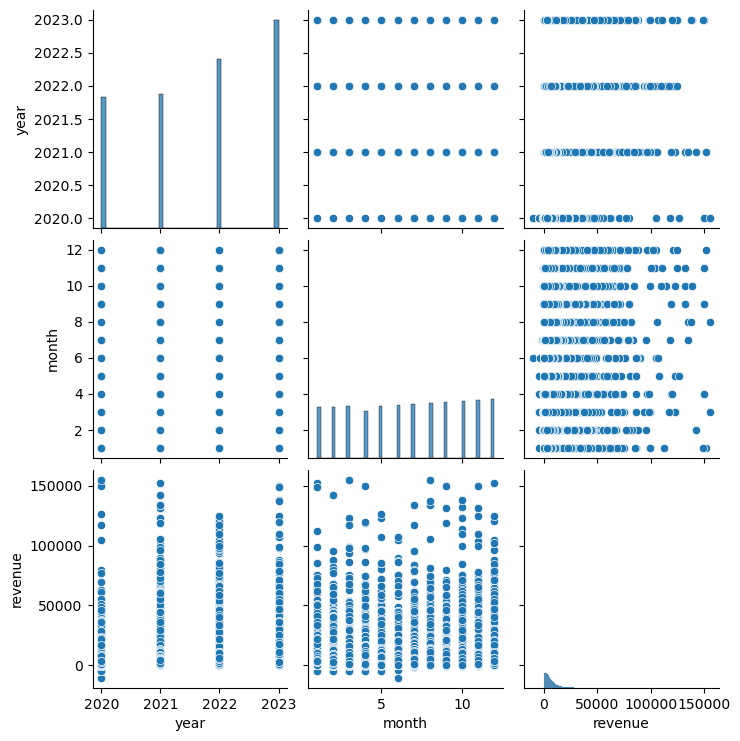

In [18]:
sns.pairplot(rev)

<Axes: xlabel='revenue'>

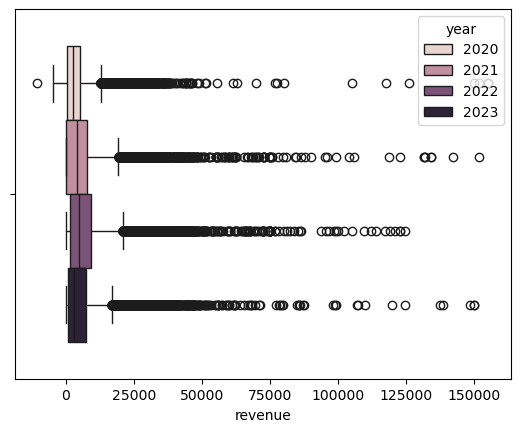

In [20]:
sns.boxplot(rev, x='revenue', hue='year')

In [16]:
merged_rev = rev.groupby('unified_id').agg({'revenue':'mean'})


In [17]:
merged_rev.head()

,revenue
unified_id,
AIR10000347,6942.595238
AIR10035983,6833.750000
AIR10052559,9530.702128
AIR10178668,9687.150000
AIR10204420,7306.925926


In [11]:
rev.info()
print("-----")
prop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146547 entries, 0 to 146546
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   unified_id  146547 non-null  object 
 1   year        146547 non-null  int64  
 2   month       146547 non-null  int64  
 3   revenue     146525 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 4.5+ MB
-----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   2126 non-null   int64 
 1   unified_id   2126 non-null   object
 2   zipcode      2126 non-null   int64 
 3   street_name  450 non-null    object
 4   city         2126 non-null   object
 5   bedrooms     2126 non-null   int64 
 6   bathrooms    2126 non-null   int64 
 7   guests       2126 non-null   int64 
 8   hot_tub      2126 non-null   bool  
 9   pool   

In [12]:
df = pd.merge(prop, rev, on='unified_id', how='right')

In [14]:
df.head()

,Unnamed: 0,unified_id,zipcode,street_name,city,bedrooms,bathrooms,guests,hot_tub,pool,year,month,revenue
0,1229.0,AIR10000347,92315.0,Cienega Road,Big Bear Lake,3.0,2.0,10.0,False,False,2023,8,2700.0
1,1229.0,AIR10000347,92315.0,Cienega Road,Big Bear Lake,3.0,2.0,10.0,False,False,2023,7,13950.0
2,1229.0,AIR10000347,92315.0,Cienega Road,Big Bear Lake,3.0,2.0,10.0,False,False,2023,6,13500.0
3,1229.0,AIR10000347,92315.0,Cienega Road,Big Bear Lake,3.0,2.0,10.0,False,False,2023,5,13950.0
4,1229.0,AIR10000347,92315.0,Cienega Road,Big Bear Lake,3.0,2.0,10.0,False,False,2023,4,13500.0


In [37]:
df['revenue'].groupby(df['unified_id']).describe()['mean']

unified_id
AIR10000347    6942.595238
AIR10035983    6833.750000
AIR10052559    9530.702128
AIR10178668    9687.150000
AIR10204420    7306.925926
                  ...     
AIR9959855     7088.936170
AIR9960008     6824.130435
AIR9976790     8438.148936
AIR9986505     8157.857143
AIR9996370     2183.979167
Name: mean, Length: 7397, dtype: float64

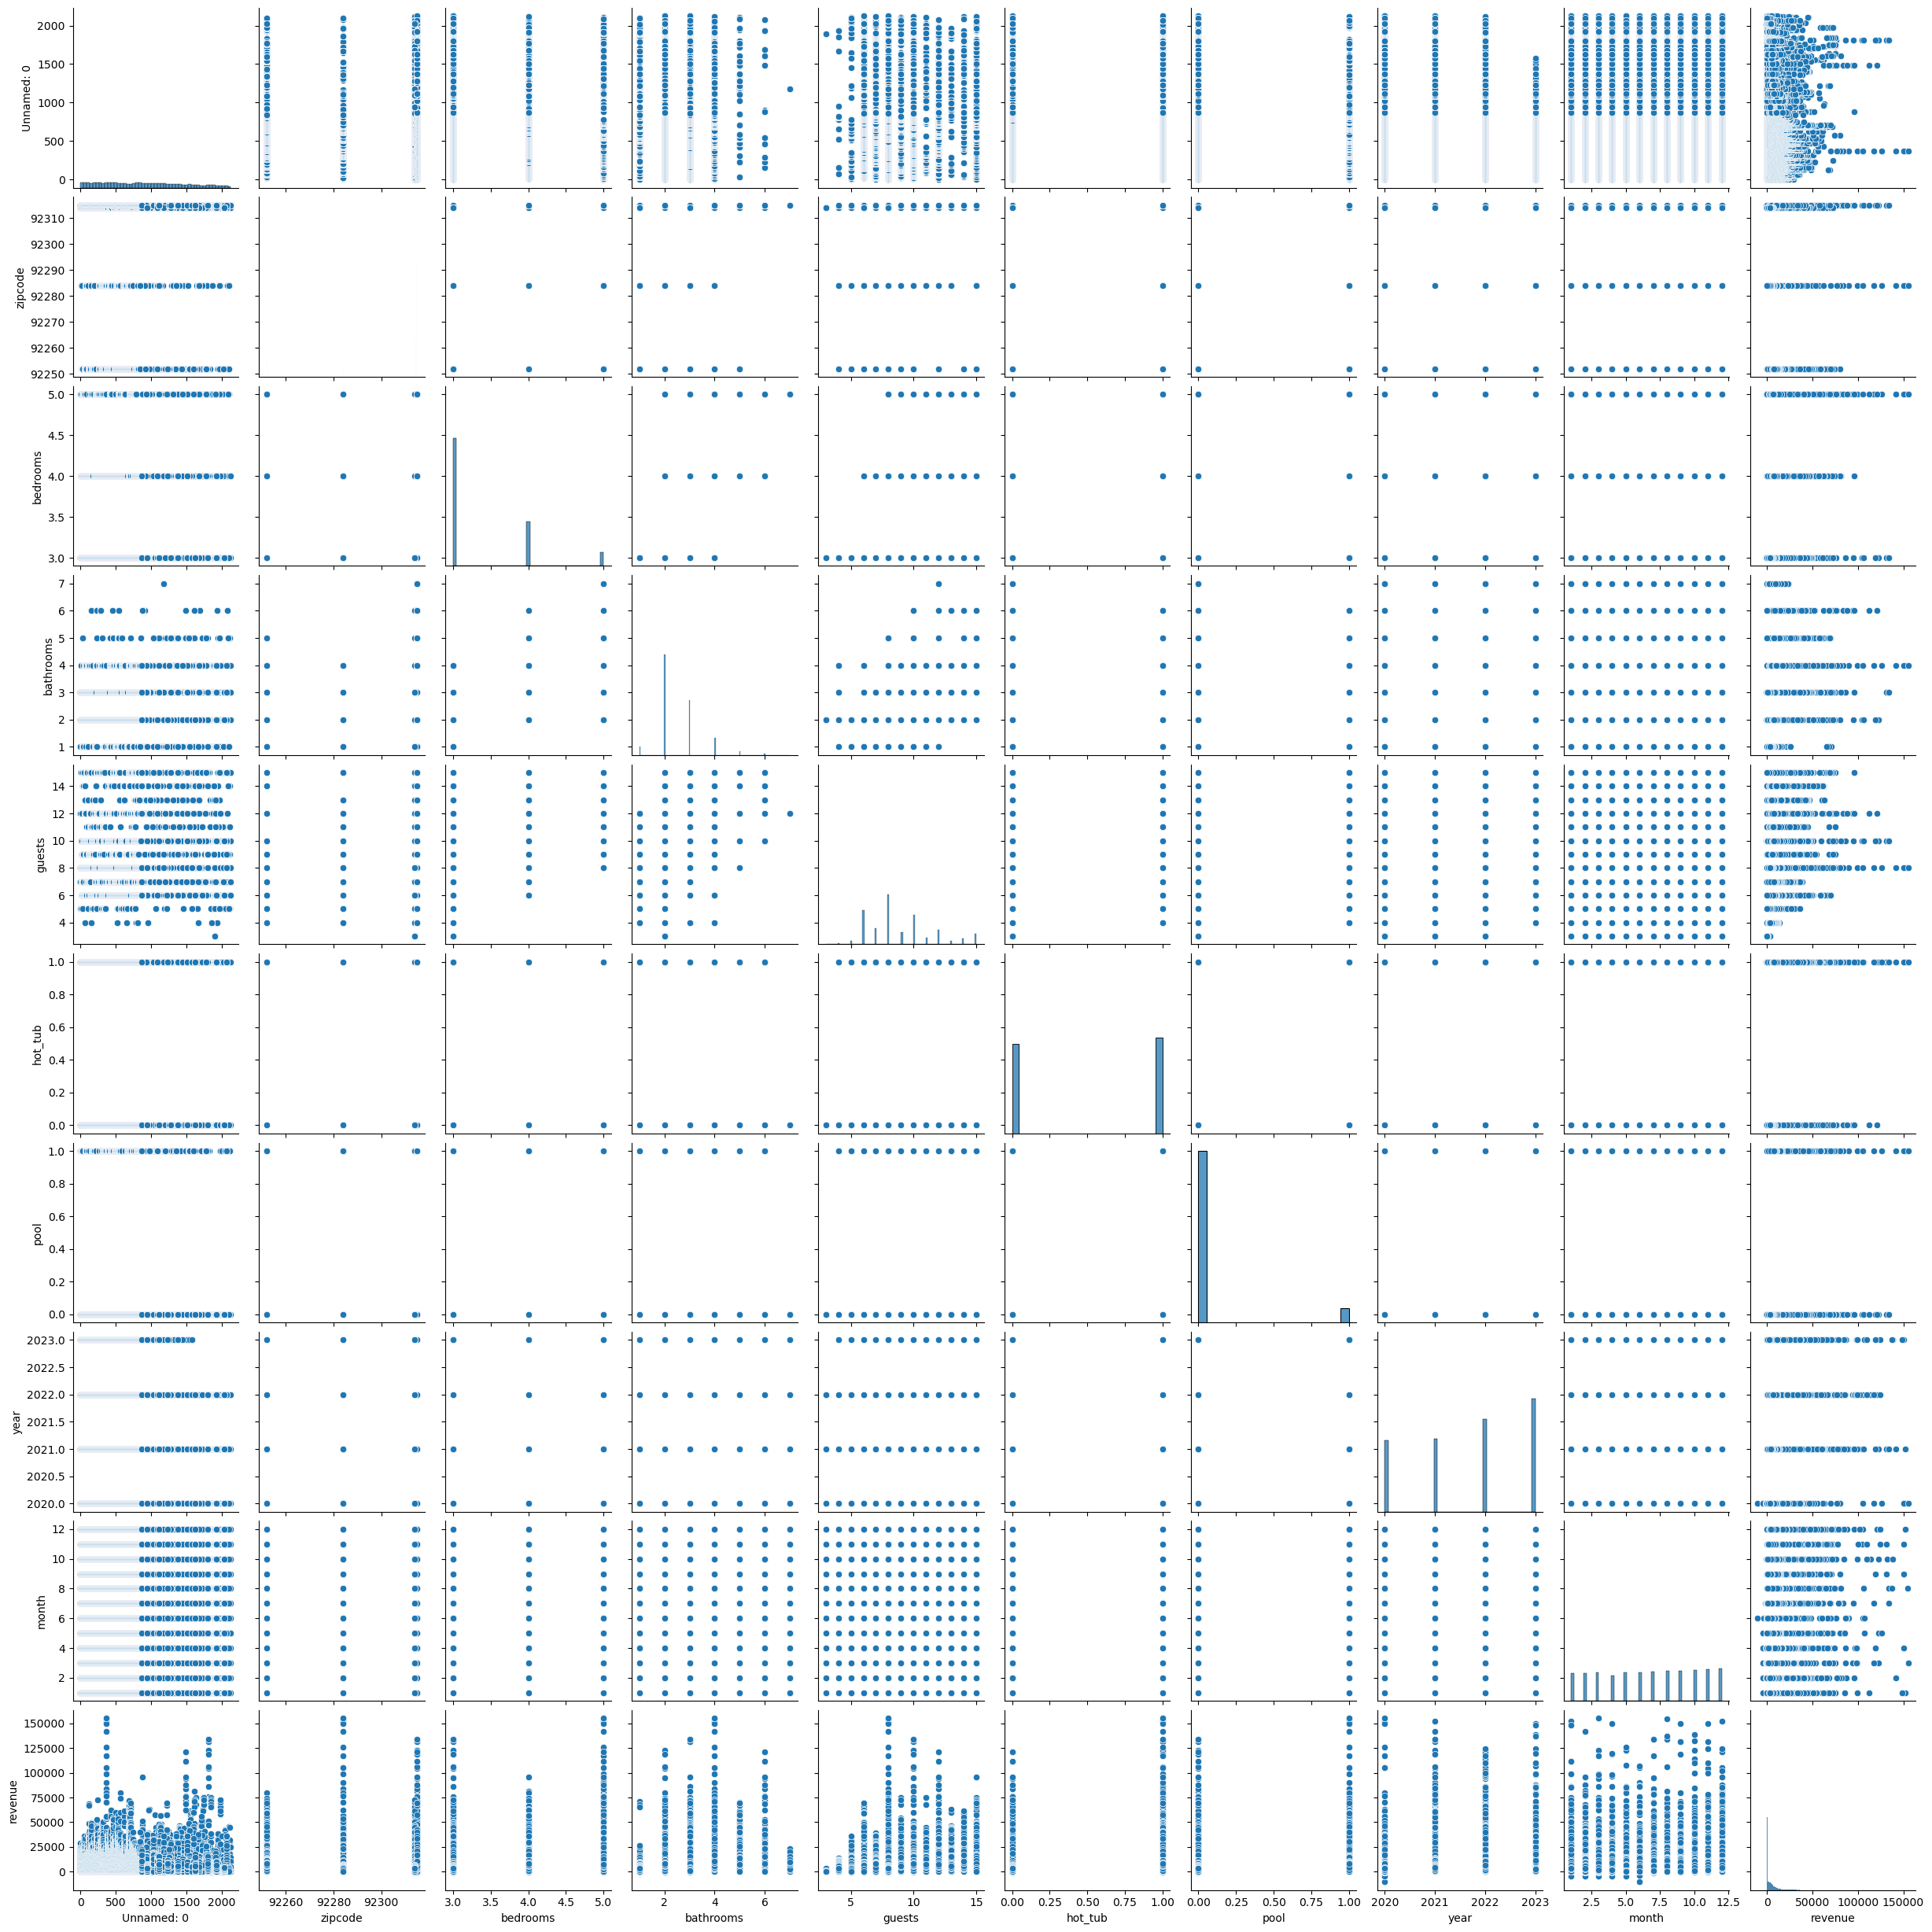

In [21]:
sns.pairplot(df)

<Axes: xlabel='revenue'>

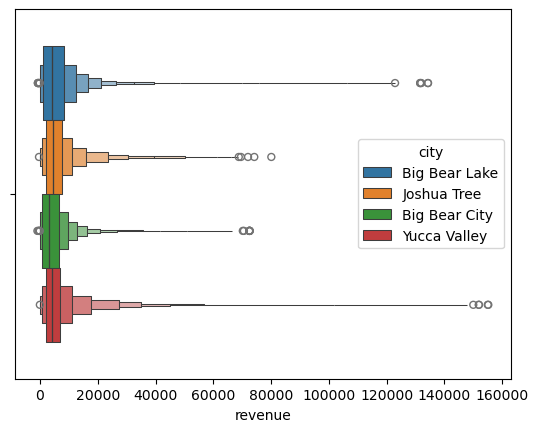

In [25]:
sns.boxenplot(df, x='revenue', hue='city')

<Axes: xlabel='revenue'>

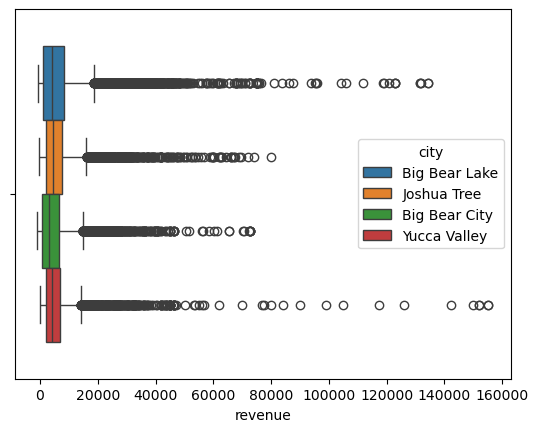

In [26]:
sns.boxplot(df, x='revenue', hue='city')

<Axes: xlabel='month', ylabel='revenue'>

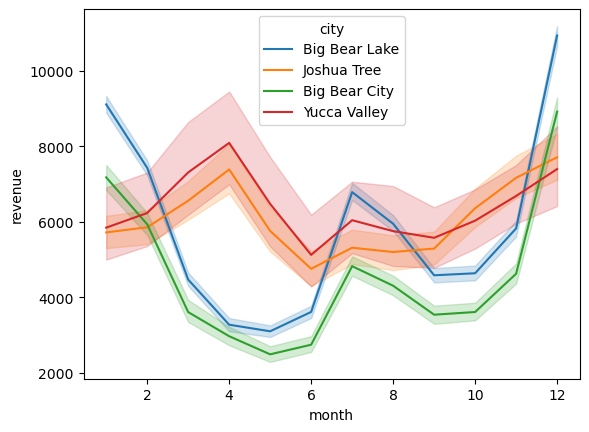

In [44]:
sns.lineplot(df, x='month', y='revenue', hue='city')

<Axes: xlabel='revenue', ylabel='Count'>

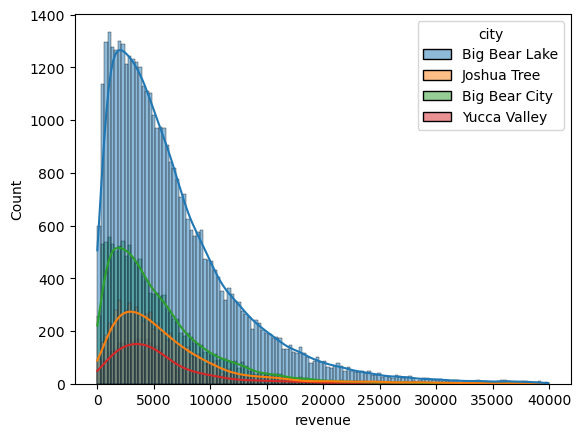

In [33]:
sns.histplot(df[(df['revenue']<40000) & (df['revenue']>0)], x='revenue', hue='city', kde=True)

<Axes: xlabel='revenue', ylabel='Count'>

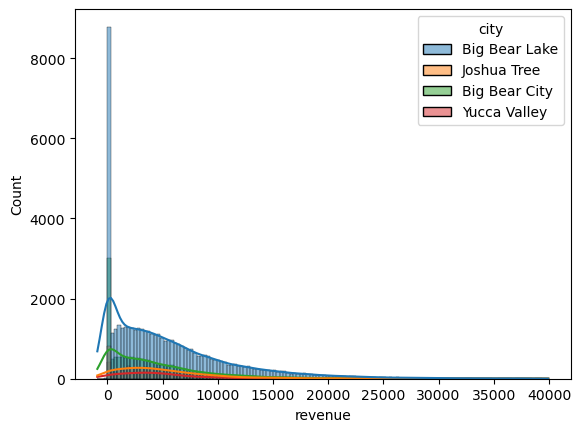

In [42]:
sns.histplot(df[(df['revenue']<40000)], x='revenue', hue='city', kde=True)

<Axes: xlabel='revenue'>

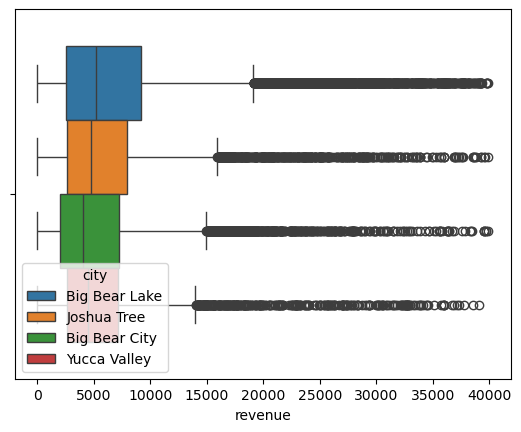

In [35]:
sns.boxplot(df[(df['revenue']<40000) & (df['revenue']>0)], x='revenue', hue='city')